# L3 —— 成纤维细胞亚群识别

In [1]:
import os, re
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
from scipy.sparse import issparse
import matplotlib.pyplot as plt
import omicverse as ov

# 路径与文件
DATA_ROOT = "/mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data"
ANNO_DIR  = os.path.join(DATA_ROOT, "06_annotation/L3/stromal"); os.makedirs(ANNO_DIR, exist_ok=True)
FIG_DIR   = os.path.join(ANNO_DIR, "figs");          os.makedirs(FIG_DIR,  exist_ok=True)
IN_PATH   = os.path.join(ANNO_DIR, "L3_stromal_annotated.h5ad")
OUT_H5AD  = os.path.join(ANNO_DIR, "L3_fibroblast_annotated.h5ad")
OUT_CSV   = os.path.join(ANNO_DIR, "L3_fibroblast_summary.csv")

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## 数据读取

In [2]:
adata = sc.read_h5ad(IN_PATH)
adata

AnnData object with n_obs × n_vars = 114604 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'GSE_colors', 'L1_lineage_colors', 'L2_celltype_colors', 'L2_celltype_sub_colors', 'REFERENCE_MANU', 'hvg', 'leiden_0.2', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.6', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

## 查看L2注释结果

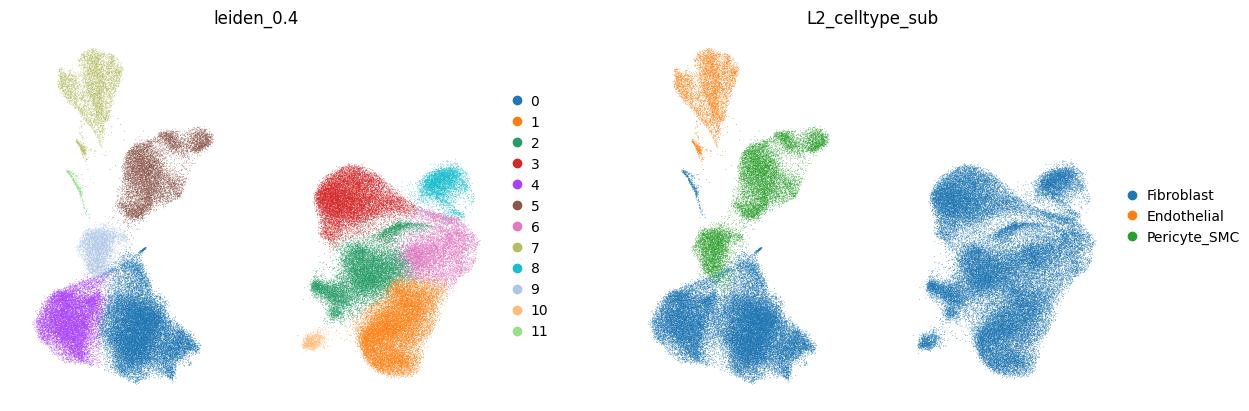

In [5]:
sc.pl.umap(adata,
           color=["leiden_0.4","L2_celltype_sub"],
           frameon=False,
           #title="L2 Epithelial Lineage Annotation",  # 英文标题
)

In [6]:
adata.obs["L2_celltype_sub"].value_counts()

L2_celltype_sub
Fibroblast      95479
Pericyte_SMC    13870
Endothelial      5255
Name: count, dtype: int64

## 对成纤维细胞进行细分

In [7]:
sub = adata[adata.obs["L2_celltype_sub"]=="Fibroblast"].copy()
sub

AnnData object with n_obs × n_vars = 95479 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'GSE_colors', 'L1_lineage_colors', 'L2_celltype_colors', 'REFERENCE_MANU', 'hvg', 'leiden_0.2', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.6', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [8]:
# 1. 删除之前的降维
for key in ["X_pca", "X_pca_harmony", "X_scVI", "X_umap"]:
    if key in sub.obsm:
        del sub.obsm[key]
# 2. 删除之前的 graph（neighbors）
for key in ["neighbors"]:
    if key in sub.uns:
        del sub.uns[key]
for key in ["distances", "connectivities"]:
    if key in sub.obsp:
        del sub.obsp[key]
# 4. 删除 var 中不再需要的高变基因标记
for key in ["highly_variable", "highly_variable_rank",
            "means", "variances", "variances_norm"]:
    if key in sub.var:
        del sub.var[key]
# 5. 删除 uns 中各种配色、聚类结果、rank_genes_groups
keys_to_remove = [
    k for k in sub.uns.keys()
    if ("colors" in k) or ("leiden" in k) or ("rank_genes_groups" in k)
]
for k in keys_to_remove:
    del sub.uns[k]

sub

AnnData object with n_obs × n_vars = 95479 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap'
    layers: 'counts'

In [9]:
# 若有原始计数，先切回 counts 再开始标准流程
if "counts" in sub.layers:
    sub.X = sub.layers["counts"]

## HVG → PCA → Harmony → neighbors → leiden

In [10]:
sc.pp.normalize_total(sub, target_sum=1e4)
sc.pp.log1p(sub)

In [11]:
sub

AnnData object with n_obs × n_vars = 95479 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap'
    layers: 'counts'

In [12]:
# 标记 HVG，但不裁剪基因
sc.pp.highly_variable_genes(
    sub, n_top_genes=2000, flavor="seurat_v3",
    subset=False, span=0.5, check_values=False
)
hv_mask = sub.var["highly_variable"].values

In [13]:
# 仅在 HVG 上做 PCA（不丢非HVG；把结果写回到 sub）
sub_hv = sub[:, hv_mask].copy()
sc.pp.scale(sub_hv, max_value=10)
sc.tl.pca(sub_hv, n_comps=50, svd_solver="arpack")
sub.obsm["X_pca"] = sub_hv.obsm["X_pca"]

In [14]:
sub

AnnData object with n_obs × n_vars = 95479 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap'
    obsm: 'X_pca'
    layers: 'counts'

In [15]:
# Harmony 去批次（基于 PCA）
sce.pp.harmony_integrate(sub, key="GSE", basis="X_pca")
sub

2025-12-02 10:42:04,755 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-12-02 10:42:14,564 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-12-02 10:42:14,927 - harmonypy - INFO - Iteration 1 of 10
2025-12-02 10:42:42,013 - harmonypy - INFO - Iteration 2 of 10
2025-12-02 10:43:09,210 - harmonypy - INFO - Iteration 3 of 10
2025-12-02 10:43:38,912 - harmonypy - INFO - Iteration 4 of 10
2025-12-02 10:44:06,368 - harmonypy - INFO - Iteration 5 of 10
2025-12-02 10:44:36,779 - harmonypy - INFO - Iteration 6 of 10
2025-12-02 10:45:03,122 - harmonypy - INFO - Iteration 7 of 10
2025-12-02 10:45:27,593 - harmonypy - INFO - Iteration 8 of 10
2025-12-02 10:45:51,997 - harmonypy - INFO - Iteration 9 of 10
2025-12-02 10:46:18,562 - harmonypy - INFO - Converged after 9 iterations


AnnData object with n_obs × n_vars = 95479 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap'
    obsm: 'X_pca', 'X_pca_harmony'
    layers: 'counts'

In [16]:
# 邻域/聚类/UMAP
sc.pp.neighbors(sub, use_rep="X_pca_harmony", n_neighbors=20)

In [17]:
sc.tl.umap(sub)

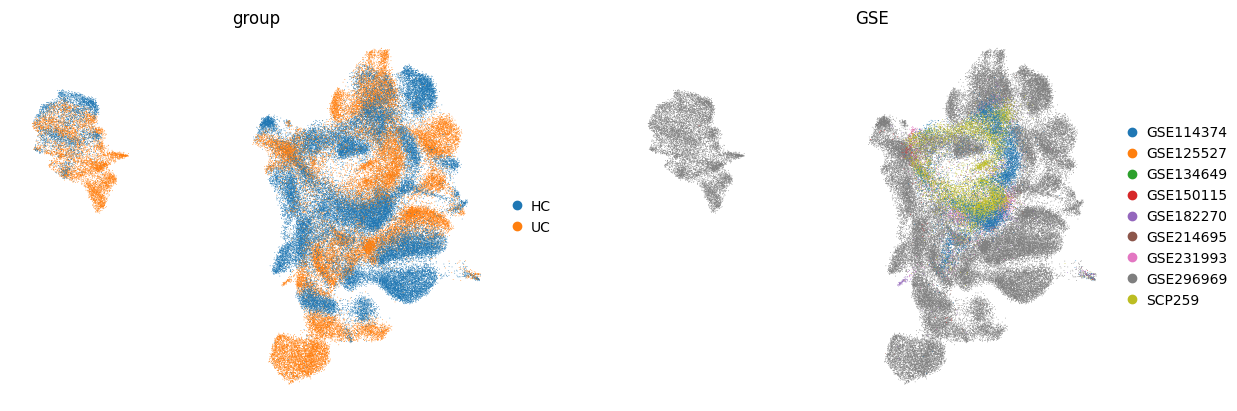

In [18]:
sc.pl.umap(sub, color=['group','GSE'], frameon=False)

In [19]:
sc.tl.leiden(sub, resolution=0.2, key_added=f"leiden_0.2_fibroblast")
sc.tl.leiden(sub, resolution=0.4, key_added=f"leiden_0.4_fibroblast")

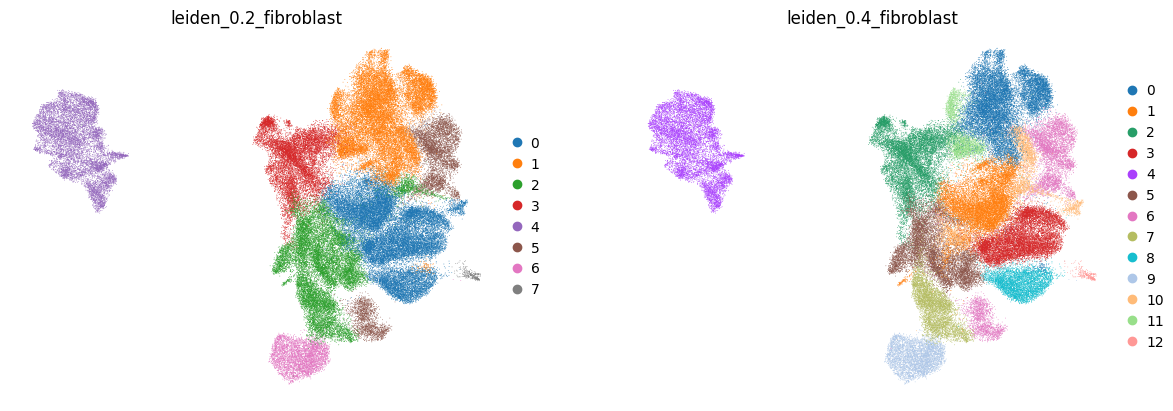

In [20]:
sc.pl.umap(sub, color=['leiden_0.2_fibroblast','leiden_0.4_fibroblast'], frameon=False)

## 通过Marker表达查看

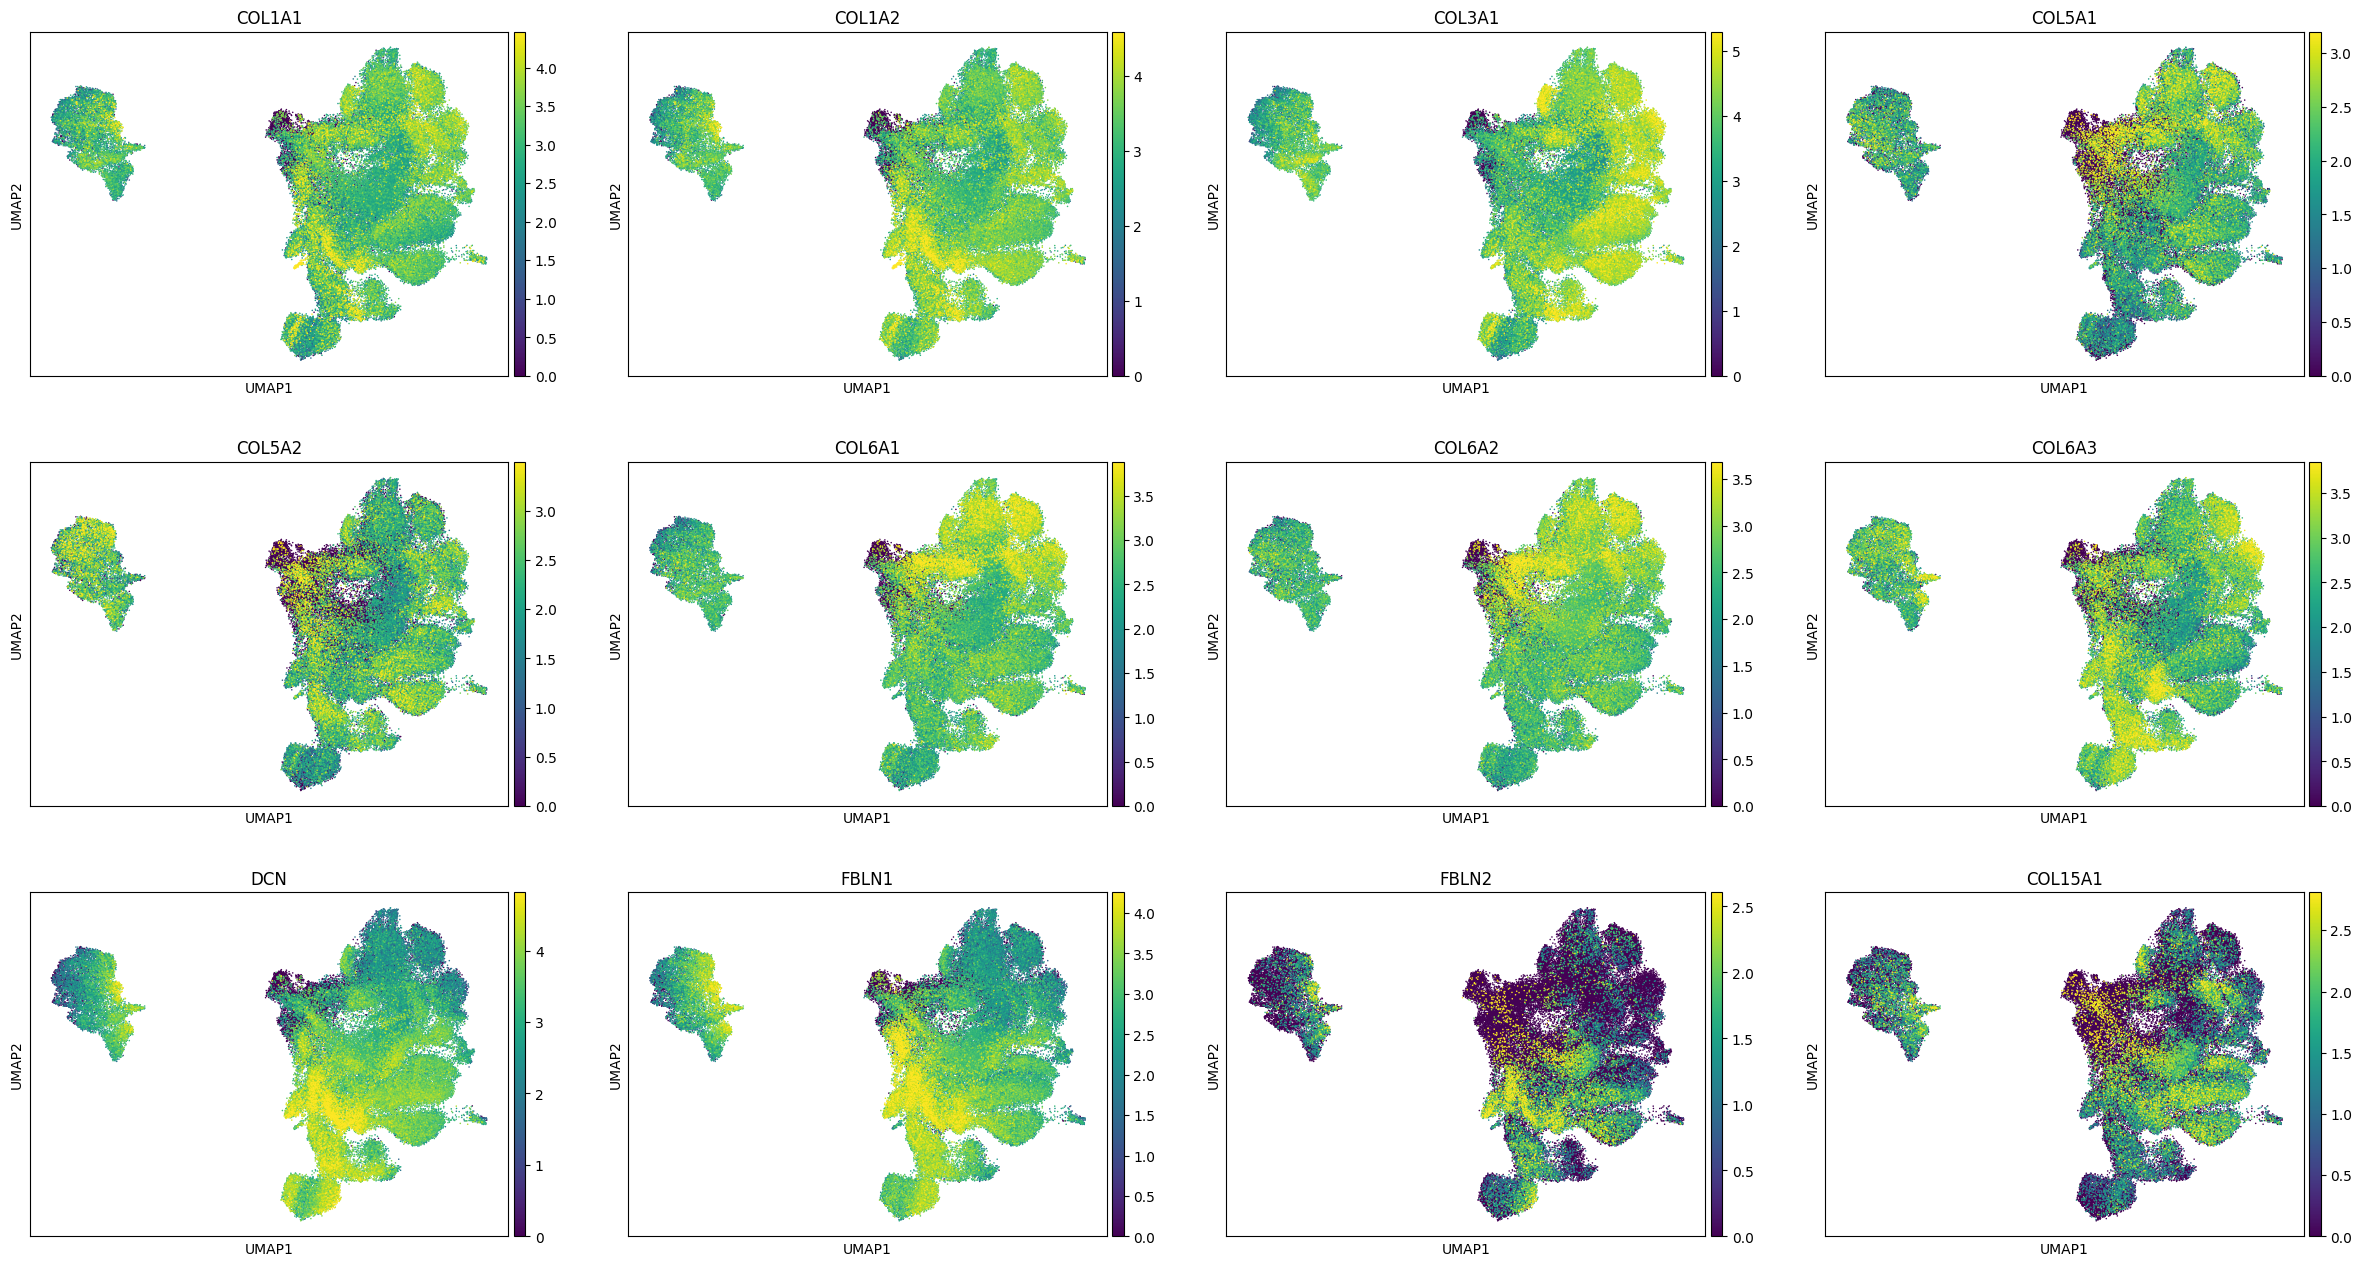

In [21]:
fibro_markers = [
    "COL1A1", "COL1A2", "COL3A1", "COL5A1", "COL5A2", "COL6A1", "COL6A2", "COL6A3", # 核心 ECM
    "DCN", "FBLN1", "FBLN2", # 基质核心蛋白
    "COL15A1" # 结肠 / 黏膜固有层特异性的 fibroblast marker
]
def safe_genes(genes, sub):
    return [g for g in genes if g in sub.var_names]

sc.pl.umap(sub, color=safe_genes(fibro_markers, sub), ncols=4, cmap="viridis", vmax="p99", vmin=0, size=5,)

### ECM

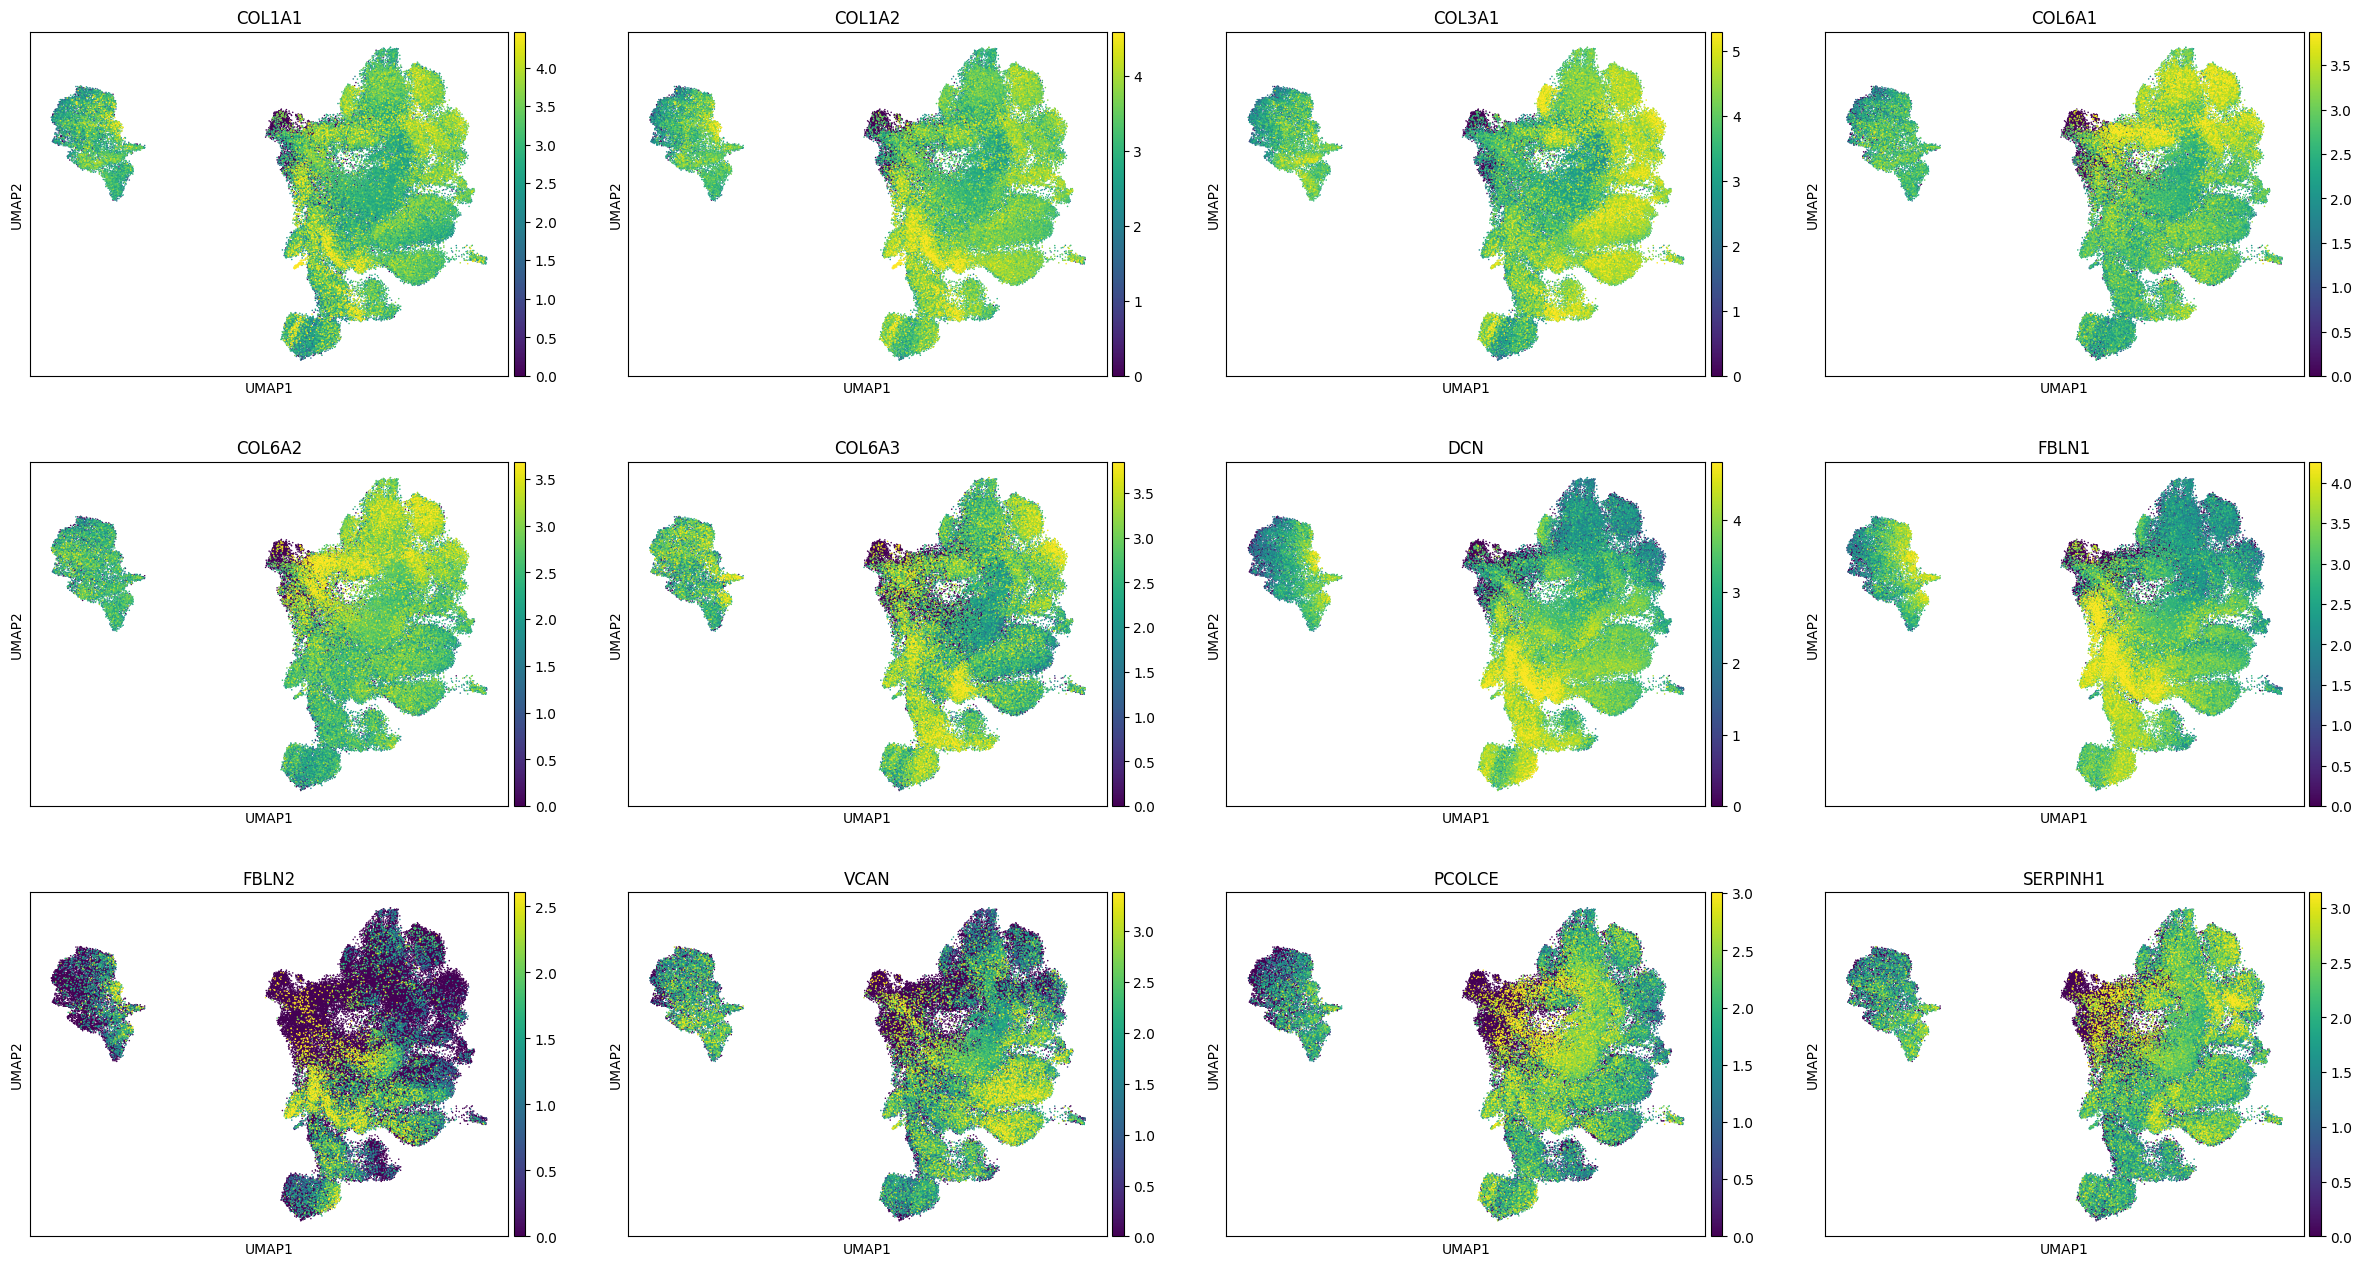

In [22]:
ecm_markers = [
        "COL1A1","COL1A2","COL3A1",
        "COL6A1","COL6A2","COL6A3",
        "DCN","LUM","BGN",
        "FBLN1","FBLN2","VCAN",
        "PCOLCE","SERPINH1"
    ]
sc.pl.umap(sub, color=safe_genes(ecm_markers, sub), ncols=4, cmap="viridis", vmax="p99", vmin=0, size=5,)

### 收缩性（肌成纤维）

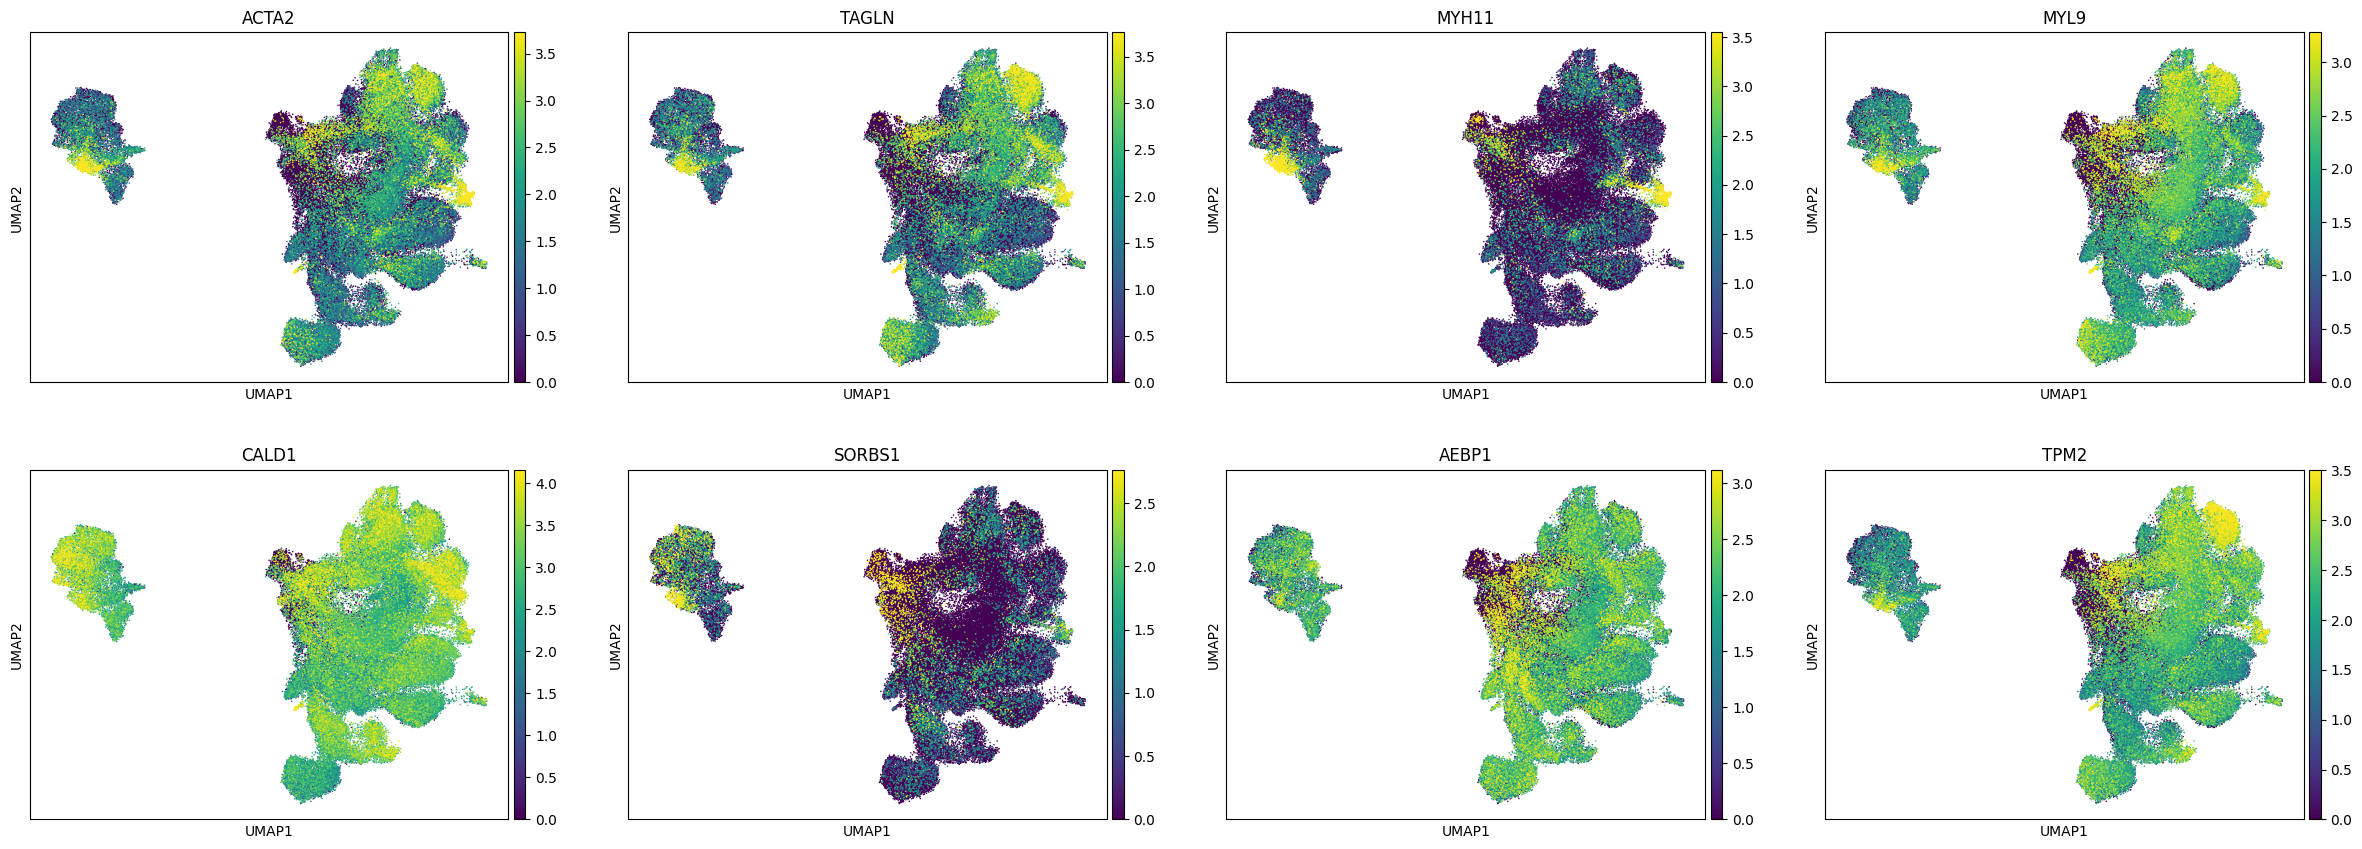

In [23]:
Myofibroblast_markers = [
        "ACTA2","TAGLN","MYH11",
        "MYL9","CNN1","CALD1",
        "SORBS1","AEBP1","TPM2",
        "DES"
    ]
sc.pl.umap(sub, color=safe_genes(Myofibroblast_markers, sub), ncols=4, cmap="viridis", vmax="p99", vmin=0, size=5,)

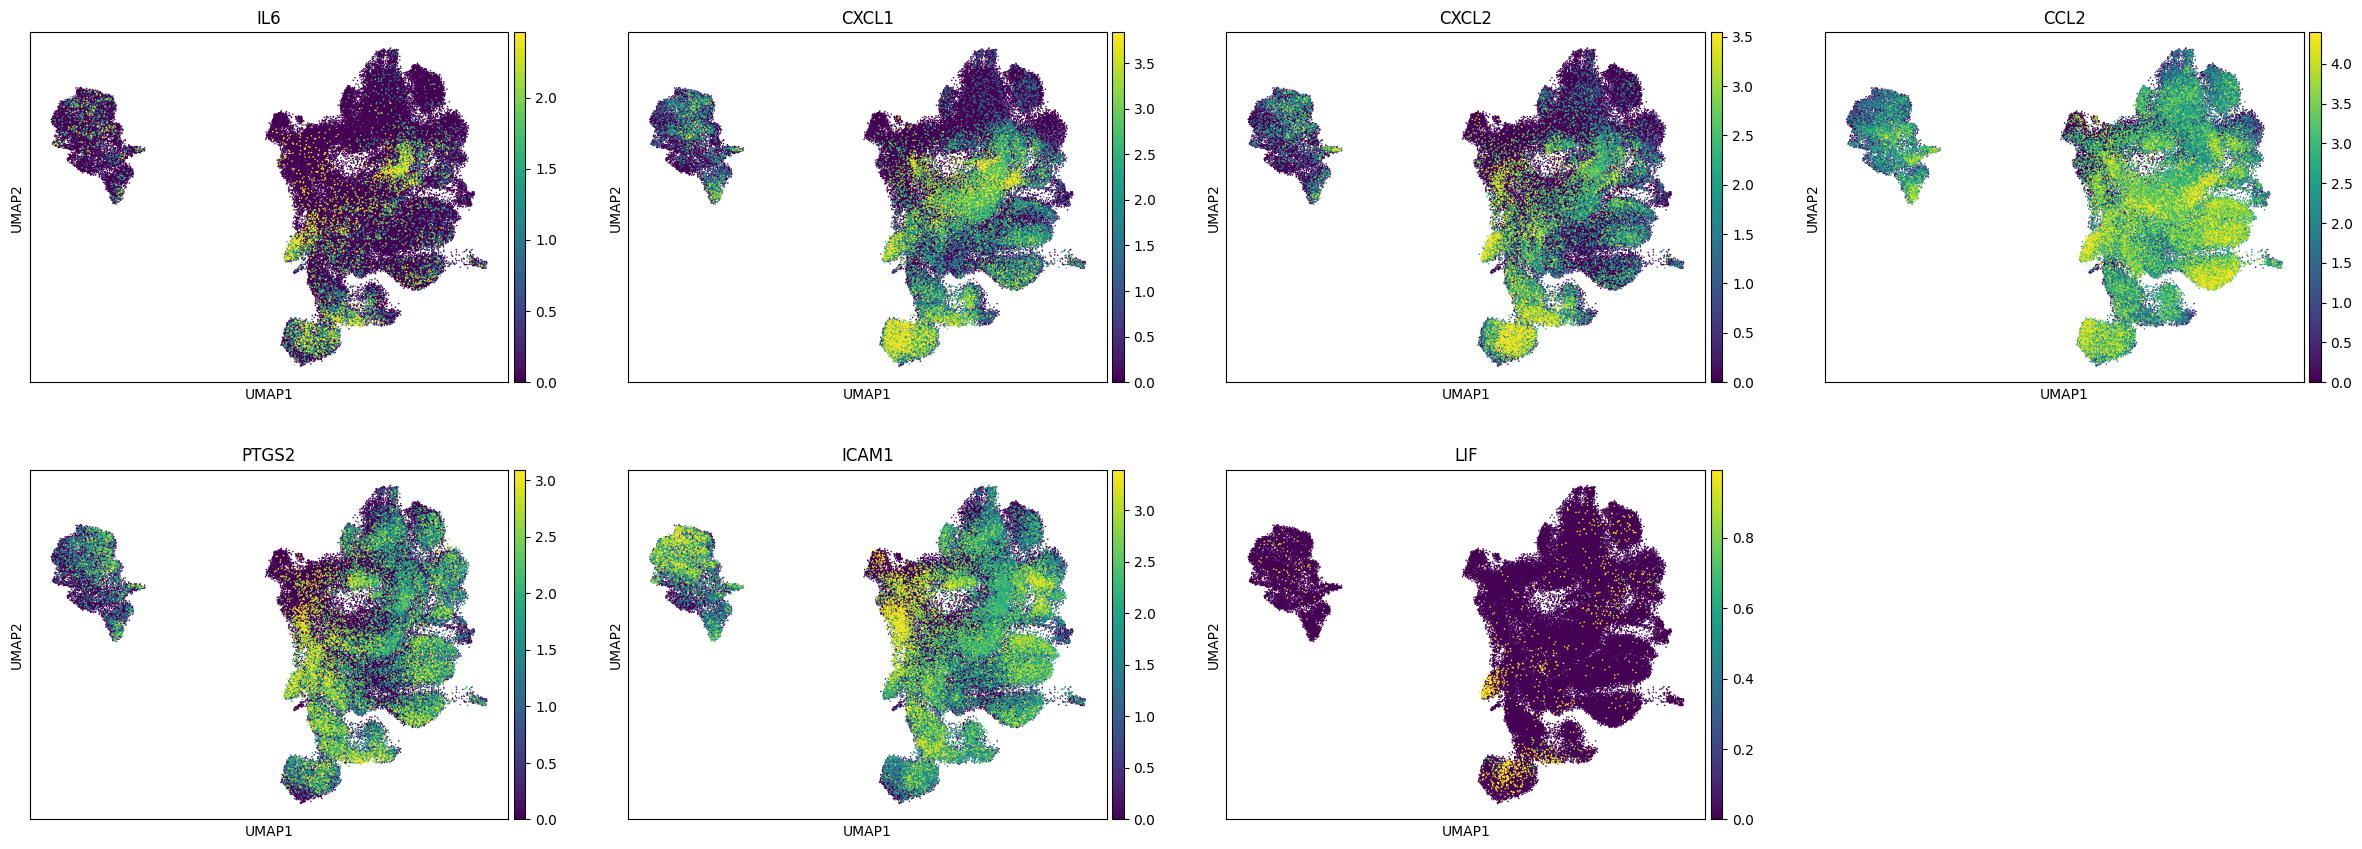

In [24]:
Inflammatory_markers = [
        "IL6","IL11",
        "CXCL8","CXCL1","CXCL2",
        "CCL2","CCL7",
        "PTGS2","ICAM1",
        "MMP3","MMP10","LIF"
    ]
sc.pl.umap(sub, color=safe_genes(Inflammatory_markers, sub), ncols=4, cmap="viridis", vmax="p99", vmin=0, size=5,)

## 差异分析

In [25]:
sub

AnnData object with n_obs × n_vars = 95479 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub', 'leiden_0.2_fibroblast', 'leiden_0.4_fibroblast'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap', 'neighbors', 'group_colors', 'GSE_colors', 'leiden_0.2_fibroblast', 'leiden_0.4_fibroblast', 'leiden_0.2_fibroblast_colors', 'leiden_0.4_fibroblast_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

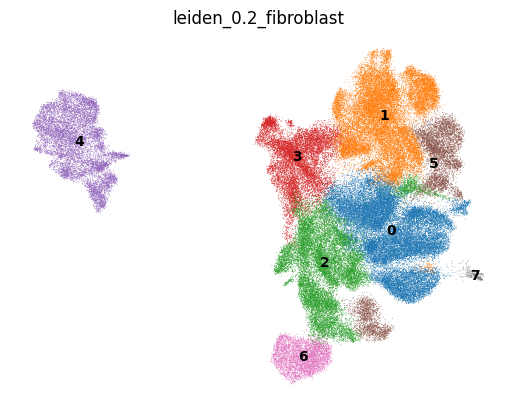

In [26]:
sc.pl.umap(sub, color=['leiden_0.2_fibroblast'], frameon=False, ncols=2, legend_loc='on data')

In [27]:
if 'leiden_0.2_fibroblast' in sub.obs.columns:
    sub.obs['leiden_0.2_fibroblast'] = sub.obs['leiden_0.2_fibroblast'].astype('category')

# 2. 运行差异分析
print("正在进行差异基因分析...")
sc.tl.rank_genes_groups(
    sub, 
    groupby='leiden_0.2_fibroblast', 
    method='wilcoxon', 
    use_raw=True, 
    pts=True
)
print("分析完成！")

正在进行差异基因分析...
分析完成！


In [28]:
# 获取所有分组的名称
groups = sub.obs['leiden_0.2_fibroblast'].cat.categories

# 初始化一个字典来存储结果
top10_genes = {}

print("=== 各亚群 Top 10 差异基因 (基于 Score 排序) ===")
for group in groups:
    # 提取该群的差异基因数据框
    df = sc.get.rank_genes_groups_df(sub, group=group)
    
    # 筛选条件：通常我们关注上调的基因 (logfoldchanges > 0)
    # 按 score 降序排列（score 综合了表达差异和显著性）
    top_genes = df[df['logfoldchanges'] > 0].sort_values('scores', ascending=False).head(10)['names'].tolist()
    
    top10_genes[group] = top_genes
    print(f"Cluster {group}: {', '.join(top_genes)}")

# 如果你想把这个 Top10 列表存成一个 DataFrame 方便查看：
df_top10 = pd.DataFrame(top10_genes)
print("\nTop 10 基因表格预览：")
#display(df_top10)

# 可选：保存到 CSV
# df_top10.to_csv("L3_TNK_Top10_Markers.csv")

=== 各亚群 Top 10 差异基因 (基于 Score 排序) ===
Cluster 0: ADAMDEC1, CTSC, APOE, FABP5, CFD, CCL2, EDIL3, TMSB10, RPS7, ADAM28
Cluster 1: F3, FRZB, CAV1, APLP2, PLAT, NSG1, PDGFD, CD9, COL6A1, ID1
Cluster 2: CCDC80, C3, MGP, DCN, FBLN1, PTGDS, CXCL12, IGFBP4, GPNMB, ADAMTS1
Cluster 3: NEAT1, SEMA4A, SIK3, AC016831.7, INTS6, FHIT, TMC5, ZSWIM6, PGLYRP2, PTPRB
Cluster 4: MALAT1, RORA, PDE4D, ZBTB20, PRKG1, LPP, DIAPH2, AC016831.7, NEAT1, MAML2
Cluster 5: HLA-B, B2M, HLA-A, TSC22D3, UBC, CALD1, COL3A1, HSPH1, F2R, ETS2
Cluster 6: IGFBP4, RPS27, RPLP0, RPLP1, TPT1, MT-CO3, RPL41, RPL37, RGS5, MT-CO1
Cluster 7: STMN1, TUBA1B, H2AFZ, HMGB2, TOP2A, SMC4, HMGB1, HMGN2, TUBB, TYMS

Top 10 基因表格预览：


## 结果

In [ ]:

sub

AnnData object with n_obs × n_vars = 95479 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub', 'leiden_0.2_fibroblast', 'leiden_0.4_fibroblast'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap', 'neighbors', 'group_colors', 'GSE_colors', 'leiden_0.2_fibroblast', 'leiden_0.4_fibroblast', 'leiden_0.2_fibroblast_colors', 'leiden_0.4_fibroblast_colors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [30]:
# 1. 定义 L3 注释映射字典
# ----------------------------------------------------------
# 这里的 Key 是您聚类结果中的数字 ID (字符串格式)
# Value 是我们确定的 L3 细胞类型名称
cluster_annotation = {
    '0': 'Inflammatory Fibro',
    '1': 'Villus-top Fibro',
    '2': 'Crypt-bottom Fibro',
    '3': 'Contaminants',   # Endothelial Cells 建议后续剔除
    '4': 'Contaminants', # Smooth Muscle Cells
    '5': 'Myofibroblasts',
    '6': 'Contaminants', # Pericytes
    '7': 'Cycling Fibroblasts'
}

In [31]:
# 2. 应用注释到新列 'L3'
# ----------------------------------------------------------
# 确保聚类列是字符串类型，以便匹配字典的 Key
cluster_col = 'leiden_0.2_fibroblast' 

if cluster_col in sub.obs.columns:
    # 创建新列 L3
    sub.obs['L3'] = sub.obs[cluster_col].astype(str).map(cluster_annotation)
    
    # 将 L3 转为 category 类型，方便后续绘图和排序
    sub.obs['L3'] = sub.obs['L3'].astype('category')
    
    print("注释已添加至 sub.obs['L3'] 列。")
    
    # 打印注释后的统计信息
    print("\n注释统计 (细胞数):")
    print(sub.obs['L3'].value_counts())

else:
    print(f"错误: 未找到列名 '{cluster_col}'，请检查您的 adata.obs。")

注释已添加至 sub.obs['L3'] 列。

注释统计 (细胞数):
L3
Contaminants           25202
Inflammatory Fibro     24595
Villus-top Fibro       21394
Crypt-bottom Fibro     17170
Myofibroblasts          6836
Cycling Fibroblasts      282
Name: count, dtype: int64


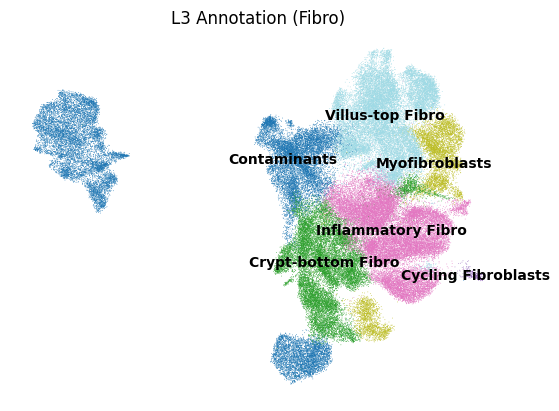

In [32]:
sc.pl.umap(
    sub, 
    color='L3', 
    title='L3 Annotation (Fibro)', 
    frameon=False, 
    legend_loc='on data',  # 标签直接标在图上
    legend_fontsize=10,
    palette='tab20'        # 使用区分度较高的色板
)

In [33]:
sub.obs.head()

,GSM,GSE,group,leiden_scVI_0.2,L1_lineage,leiden_0.4,L2_celltype_sub,leiden_0.2_fibroblast,leiden_0.4_fibroblast,L3
GSM8980878_UC68_CELL6_N4,GSM8980878,GSE296969,UC,1,Stromal,8,Fibroblast,3,2,Contaminants
GSM8980878_UC68_CELL14_N2,GSM8980878,GSE296969,UC,1,Stromal,2,Fibroblast,4,4,Contaminants
GSM8980878_UC68_CELL20_N5,GSM8980878,GSE296969,UC,5,Stromal,6,Fibroblast,4,4,Contaminants
GSM8980878_UC68_CELL21_N3,GSM8980878,GSE296969,UC,1,Stromal,6,Fibroblast,4,4,Contaminants
GSM8980878_UC68_CELL26_N2,GSM8980878,GSE296969,UC,5,Stromal,3,Fibroblast,1,0,Villus-top Fibro


In [34]:
import os
import matplotlib.pyplot as plt

# 绘制并保存 UMAP 图
fig_path = os.path.join(FIG_DIR, "L3_Fibro_annotation_UMAP.png")

sc.pl.umap(
    sub,
    color=["L3"],
    frameon=False,
    title="L3 Fibro annotation",  # 英文标题
    save=None,  # 我们手动保存，不用 Scanpy 自动保存
    show=False  # 防止 Notebook 中立即弹出
)

# 手动保存图片（可控格式和分辨率）
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.close()

print(f"[Saved figure] → {fig_path}")


[Saved figure] → /mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data/06_annotation/L3/stromal/figs/L3_Fibro_annotation_UMAP.png


In [35]:
sub

AnnData object with n_obs × n_vars = 95479 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub', 'leiden_0.2_fibroblast', 'leiden_0.4_fibroblast', 'L3'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap', 'neighbors', 'group_colors', 'GSE_colors', 'leiden_0.2_fibroblast', 'leiden_0.4_fibroblast', 'leiden_0.2_fibroblast_colors', 'leiden_0.4_fibroblast_colors', 'rank_genes_groups', 'L3_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [36]:
wanted_cols = [
    "GSM", "GSE", "group",
    "L1_lineage"             
    "L2_celltype_sub",        # 最终子类（回收后已含 Other）
    'L3'
]
out_cols = [c for c in wanted_cols if c in sub.obs.columns]

sub.obs[out_cols].to_csv(OUT_CSV, index=True)
print(f"[Saved per-cell table] -> {OUT_CSV}")

[Saved per-cell table] -> /mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data/06_annotation/L3/stromal/L3_fibroblast_summary.csv


In [37]:
sub.write_h5ad(OUT_H5AD, compression="gzip")